# Cyclic Encoding & Discretization
**ShipmentSure — Predicting On-Time Delivery**

- Cyclic encoding using sine and cosine transforms
- Three binning strategies: equal-width, equal-frequency, KBinsDiscretizer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Train.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
# Cyclic Encoding — applied to Customer_rating (scale 1-5) as a demo
# (In a real-time dataset, this would apply to Order_Hour: 0-23)
period = 5   # range of Customer_rating is 1–5

df['rating_sin'] = np.sin(2 * np.pi * df['Customer_rating'] / period)
df['rating_cos'] = np.cos(2 * np.pi * df['Customer_rating'] / period)

print("Cyclic encoded values (Customer_rating):")
df[['Customer_rating', 'rating_sin', 'rating_cos']].drop_duplicates().sort_values('Customer_rating')

Cyclic encoded values (Customer_rating):


,Customer_rating,rating_sin,rating_cos
5,1,9.510565e-01,0.309017
1,2,5.877853e-01,-0.809017
3,3,-5.877853e-01,-0.809017
8,4,-9.510565e-01,0.309017
0,5,-2.449294e-16,1.000000


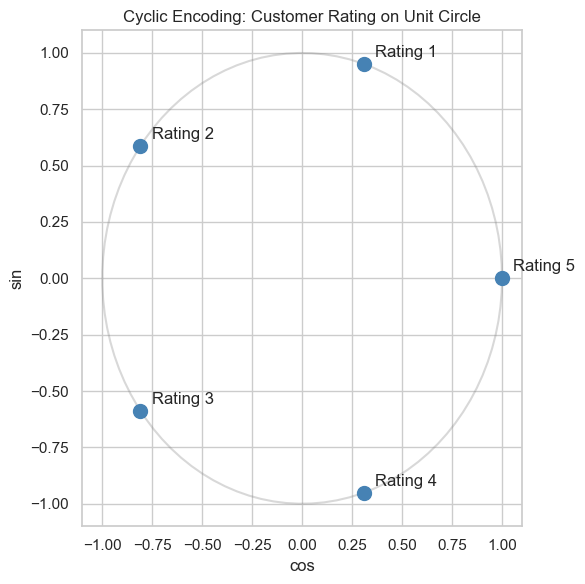

In [4]:
# Visualize cyclic encoding on a unit circle
plt.figure(figsize=(6, 6))
ratings = df[['Customer_rating', 'rating_sin', 'rating_cos']].drop_duplicates().sort_values('Customer_rating')
plt.scatter(ratings['rating_cos'], ratings['rating_sin'], s=100, c='steelblue', zorder=5)
for _, row in ratings.iterrows():
    plt.annotate(f"Rating {int(row['Customer_rating'])}",
                 (row['rating_cos'], row['rating_sin']),
                 textcoords='offset points', xytext=(8, 5))
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'gray', alpha=0.3)
plt.title('Cyclic Encoding: Customer Rating on Unit Circle')
plt.xlabel('cos')
plt.ylabel('sin')
plt.tight_layout()
plt.show()

In [5]:
# Discretization — Equal-width binning (pd.cut)
df['Cost_bin_cut'] = pd.cut(
    df['Cost_of_the_Product'], bins=4,
    labels=['Low', 'Medium', 'High', 'Premium']
)
print("Equal-width bins (pd.cut) for Cost:")
print(df['Cost_bin_cut'].value_counts())

Equal-width bins (pd.cut) for Cost:
Cost_bin_cut
High       268
Premium    249
Low        243
Medium     240
Name: count, dtype: int64


In [6]:
# Equal-frequency binning (pd.qcut)
df['Cost_bin_qcut'] = pd.qcut(
    df['Cost_of_the_Product'], q=4,
    labels=['Low', 'Medium', 'High', 'Premium']
)
print("Equal-frequency bins (pd.qcut) for Cost:")
print(df['Cost_bin_qcut'].value_counts())

Equal-frequency bins (pd.qcut) for Cost:
Cost_bin_qcut
Low        252
High       251
Premium    249
Medium     248
Name: count, dtype: int64


In [7]:
# KBinsDiscretizer
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
df['Cost_bin_kbd'] = kbd.fit_transform(df[['Cost_of_the_Product']]).astype(int)
print("KBinsDiscretizer bins:")
print(df['Cost_bin_kbd'].value_counts().sort_index())

KBinsDiscretizer bins:
Cost_bin_kbd
0    248
1    252
2    245
3    255
Name: count, dtype: int64


S:\C\Anaconda\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


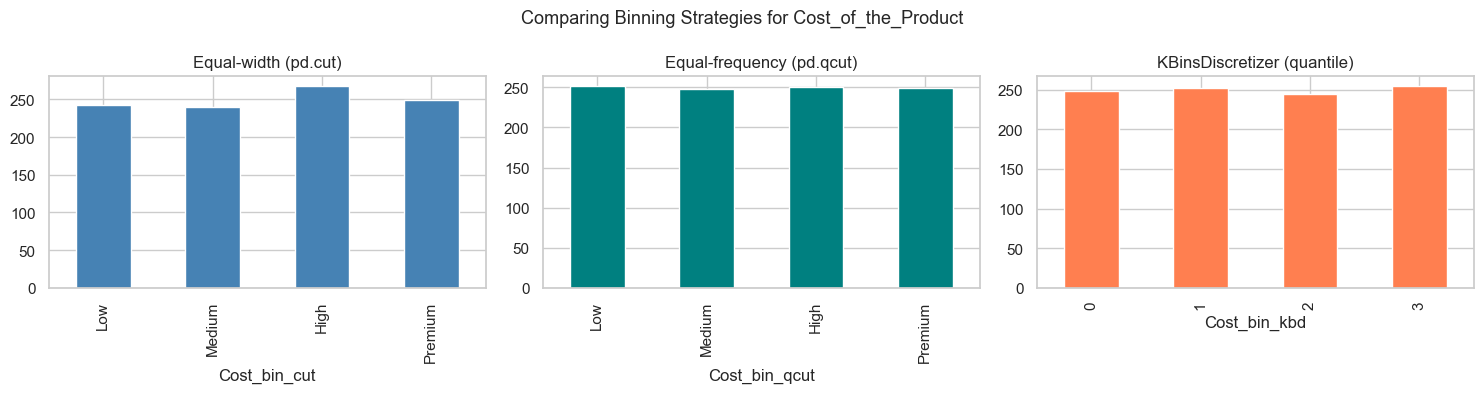

In [8]:
# Compare binning strategies
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Comparing Binning Strategies for Cost_of_the_Product', fontsize=13)

df['Cost_bin_cut'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Equal-width (pd.cut)')

df['Cost_bin_qcut'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Equal-frequency (pd.qcut)')

df['Cost_bin_kbd'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('KBinsDiscretizer (quantile)')

plt.tight_layout()
plt.show()